# Лабораторная работа: Применение дерева решений для задач классификации
## Датасет: Seeds (UCI Machine Learning Repository)

### Пункт 4. Обучение модели

### 4.1. Загрузка и подготовка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Загрузка датасета
columns_names = ['area', 'perimeter', 'compactness', 'kernel_length', 
                 'kernel_width', 'asymmetry_coeff', 'groove_length', 'target']

seed = 4403

df = pd.read_csv('Seed/Seed_Data.csv', header=0, names=columns_names)
df.head()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coeff,groove_length,target
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,0


In [2]:
# Проверка на пропущенные значения
print("Проверка на пропущенные значения:")
print(df.isnull().sum())

Проверка на пропущенные значения:
area               0
perimeter          0
compactness        0
kernel_length      0
kernel_width       0
asymmetry_coeff    0
groove_length      0
target             0
dtype: int64


In [3]:
# Описательная статистика
print("Описательная статистика:")
print(df.describe())

Описательная статистика:
             area   perimeter  compactness  kernel_length  kernel_width  \
count  210.000000  210.000000   210.000000     210.000000    210.000000   
mean    14.847524   14.559286     0.870999       5.628533      3.258605   
std      2.909699    1.305959     0.023629       0.443063      0.377714   
min     10.590000   12.410000     0.808100       4.899000      2.630000   
25%     12.270000   13.450000     0.856900       5.262250      2.944000   
50%     14.355000   14.320000     0.873450       5.523500      3.237000   
75%     17.305000   15.715000     0.887775       5.979750      3.561750   
max     21.180000   17.250000     0.918300       6.675000      4.033000   

       asymmetry_coeff  groove_length      target  
count       210.000000     210.000000  210.000000  
mean          3.700201       5.408071    1.000000  
std           1.503557       0.491480    0.818448  
min           0.765100       4.519000    0.000000  
25%           2.561500       5.045000  

In [4]:
# Сбалансированность классов
print("Распределение классов:")
print(df['target'].value_counts())

Распределение классов:
target
0    70
1    70
2    70
Name: count, dtype: int64


### 4.2. Разделение на обучающую и тестовую выборки

In [5]:
# Разделение на признаки и целевую переменную
X = df.drop('target', axis=1)
y = df['target']

# Разделение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

print(f"Размер обучающей выборки: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Размер тестовой выборки: X_test={X_test.shape}, y_test={y_test.shape}")

Размер обучающей выборки: X_train=(168, 7), y_train=(168,)
Размер тестовой выборки: X_test=(42, 7), y_test=(42,)


### 4.3. Построение дерева решений

In [6]:
# Обучение базовой модели (без ограничения глубины)
dt_base = DecisionTreeClassifier(criterion='gini', random_state=seed)
dt_base.fit(X_train, y_train)
y_pred_base = dt_base.predict(X_test)

accuracy_base = accuracy_score(y_test, y_pred_base)
print(f"Точность базовой модели (без ограничения глубины): {accuracy_base:.4f}")

Точность базовой модели (без ограничения глубины): 0.9762


In [7]:
# Эксперименты с ограничением глубины дерева
print("Сравнение точности при разной глубине дерева:")
print(f"{'Глубина':<10} {'Точность':<10}")
print("-" * 20)

results = []
best = {
    'depth': 0,
    'accuracy': 0
}
for depth in [2, 3, 4, 5]:
    dt = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=seed)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((depth, acc))
    
    if (acc > best['accuracy']):
        best['accuracy'] = acc
        best['depth'] = depth
    
    print(f"{depth:<10} {acc:.4f}")

Сравнение точности при разной глубине дерева:
Глубина    Точность  
--------------------
2          0.9048
3          0.9048
4          0.9286
5          0.9524


In [8]:
# Выбираем модель с наибольшей точностью
dt_best = DecisionTreeClassifier(criterion='gini', max_depth=best['depth'], random_state=seed)
dt_best.fit(X_train, y_train)
y_pred_best = dt_best.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)

print(f"Выбрана модель с max_depth={best['depth']}, точность: {accuracy_best:.4f}")

Выбрана модель с max_depth=5, точность: 0.9524


### 4.4. Визуализация дерева решений

Дерево сохранено в decision_tree.png


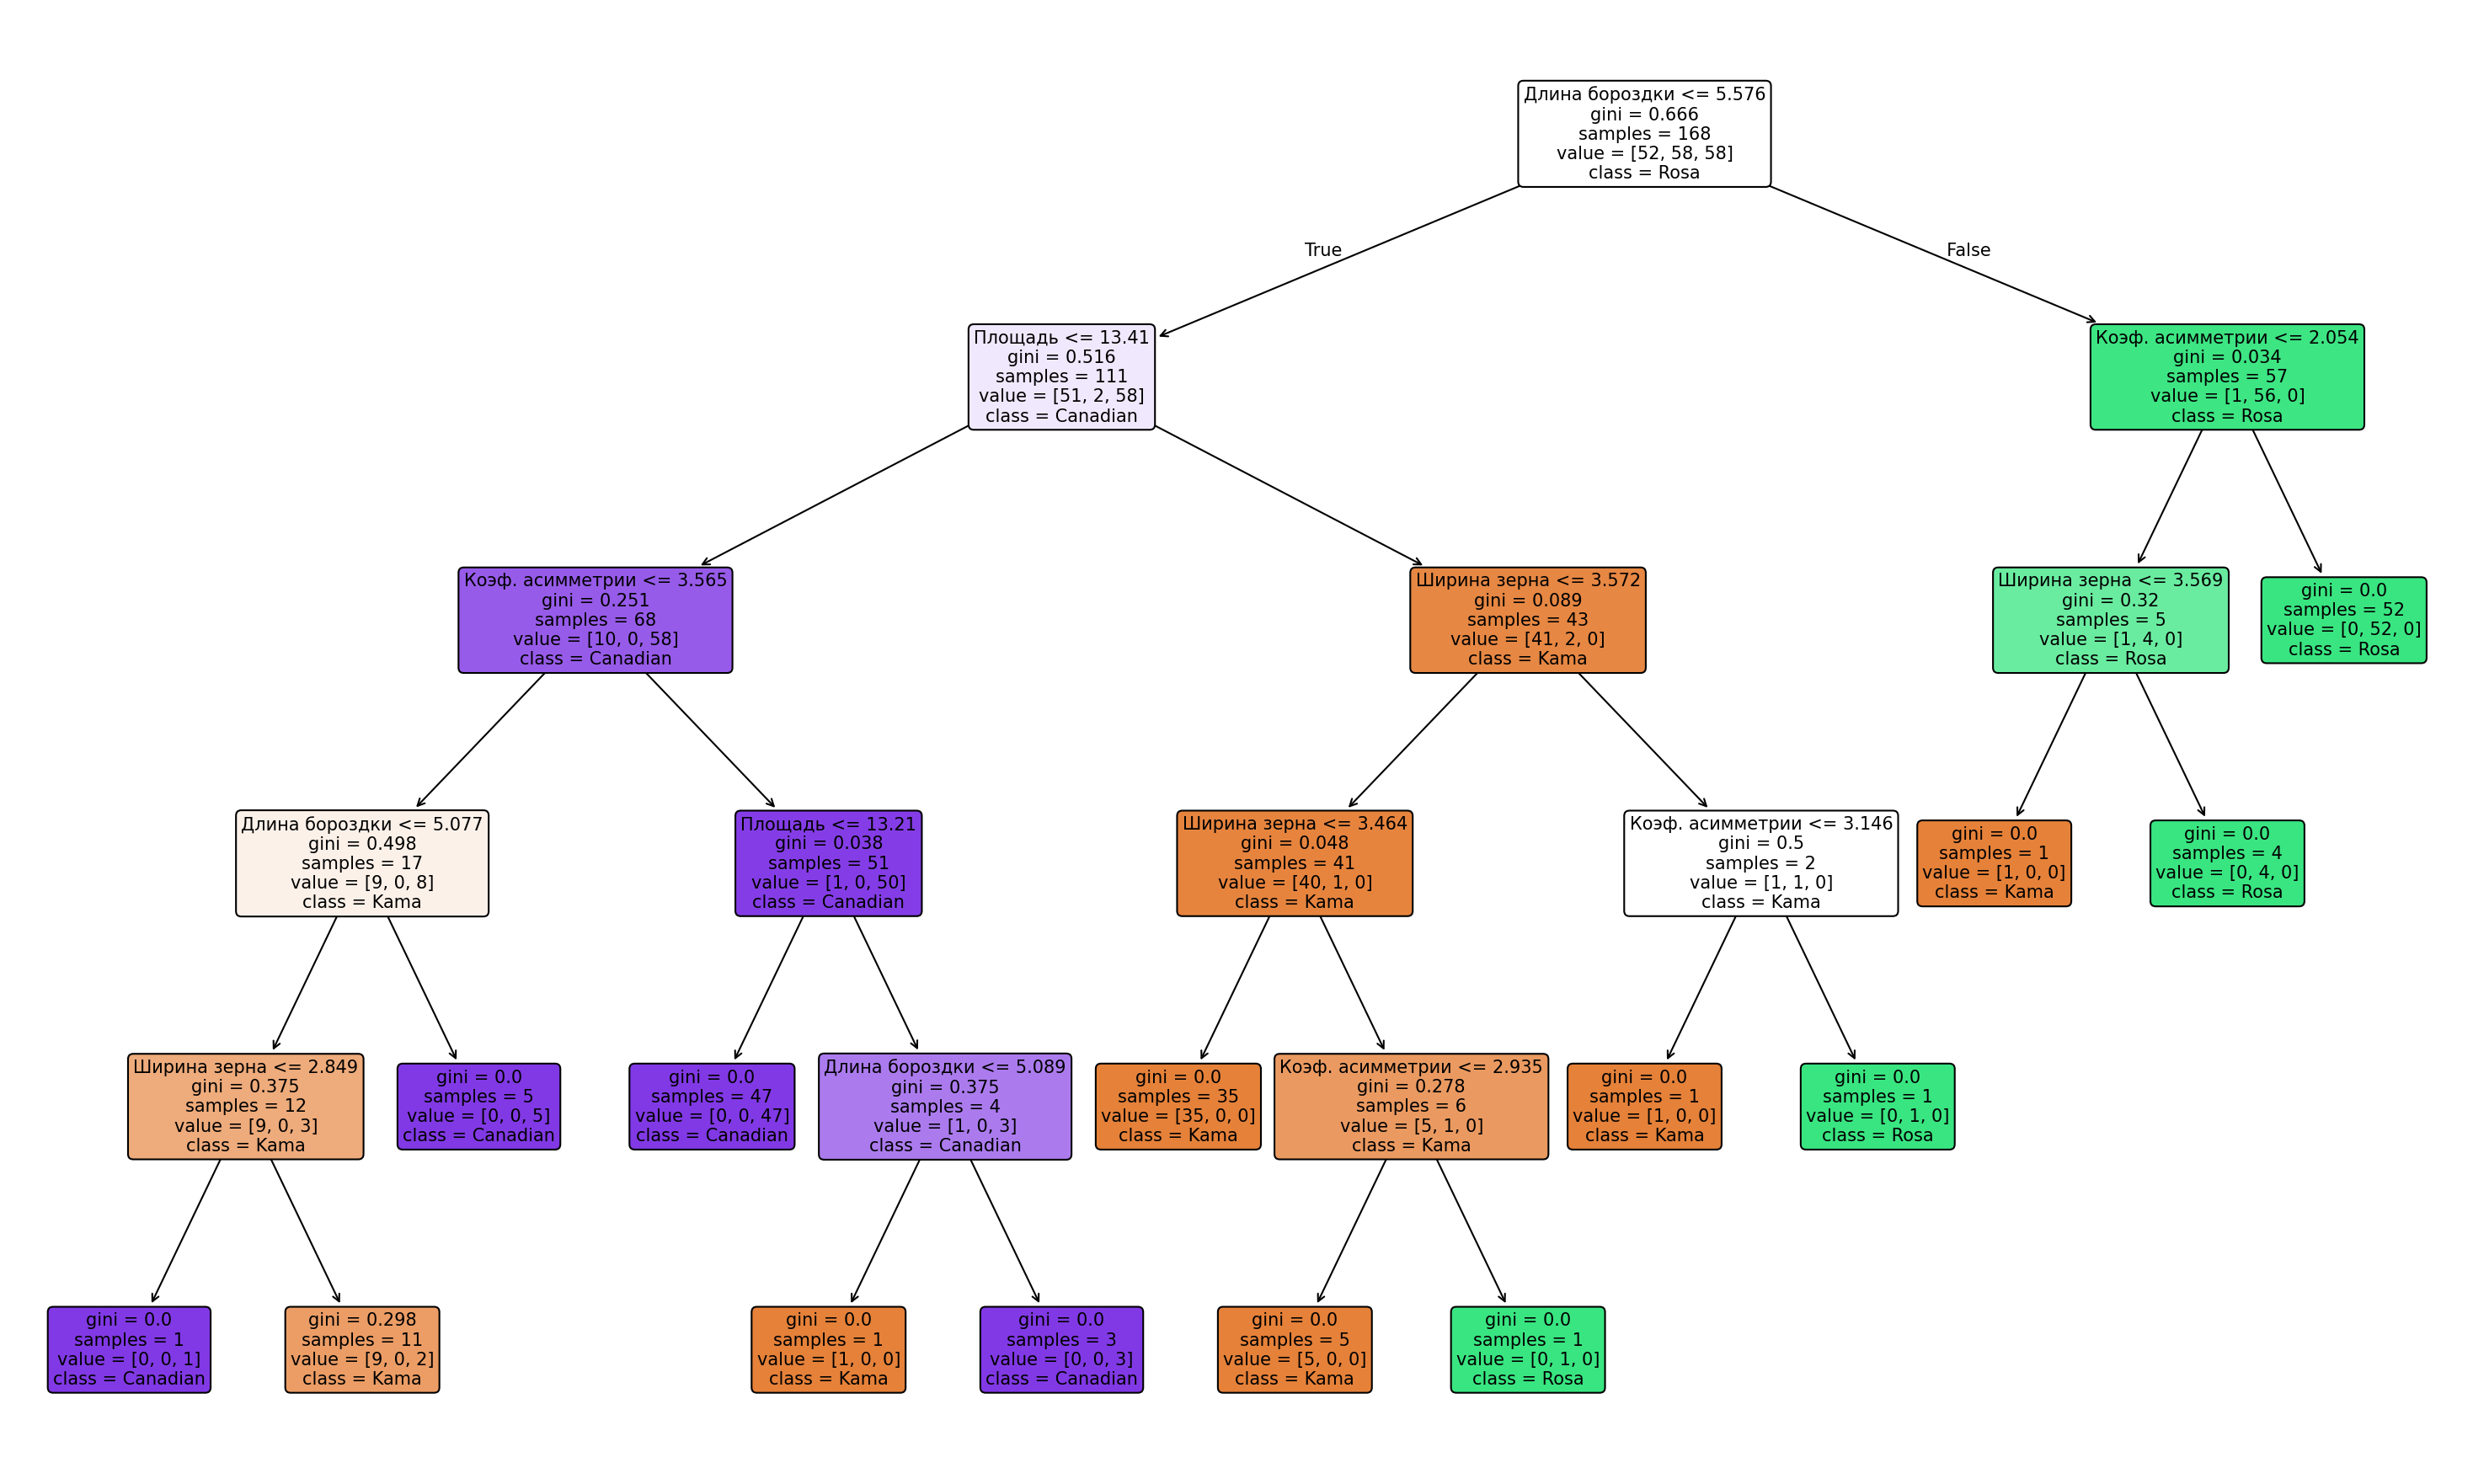

In [9]:
# Названия признаков на русском языке
feature_names_ru = [
    'Площадь',
    'Периметр',
    'Компактность',
    'Длина зерна',
    'Ширина зерна',
    'Коэф. асимметрии',
    'Длина бороздки'
]

class_names = ['Kama', 'Rosa', 'Canadian']

# Визуализация дерева
plt.figure(figsize=(25, 15))
plot_tree(dt_best, 
          feature_names=feature_names_ru,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.close()

print("Дерево сохранено в decision_tree.png")

# Отображение дерева в ноутбуке
from IPython.display import Image
Image(filename='decision_tree.png')

In [10]:
# Экспорт дерева в DOT-формат
dot_data = export_graphviz(dt_best,
                           out_file=None,
                           feature_names=feature_names_ru,
                           class_names=class_names,
                           filled=True,
                           rounded=True)

with open('decision_tree.dot', 'w', encoding='utf-8') as f:
    f.write(dot_data)

print("Дерево сохранено в decision_tree.dot")

Дерево сохранено в decision_tree.dot


### 4.5. Оценка качества модели

In [11]:
# Общая точность
print(f"Общая точность классификации: {accuracy_best:.4f}")

Общая точность классификации: 0.9524


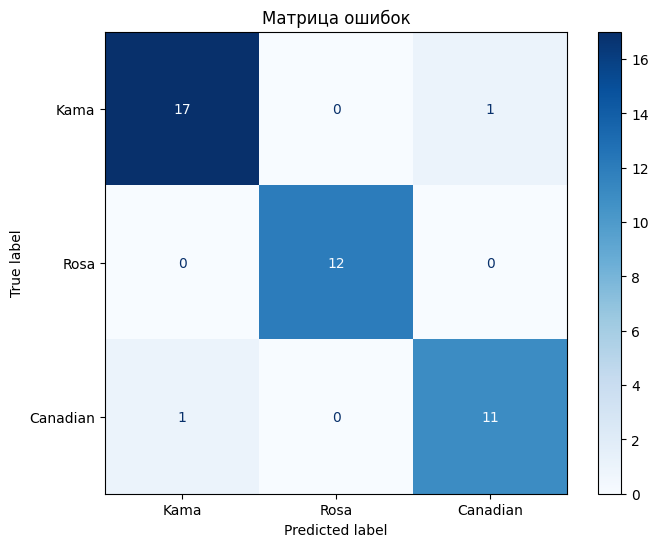

In [12]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Матрица ошибок')
plt.show()

In [13]:
# Подробный отчёт по каждому классу
print("Подробный отчёт по каждому классу:")
print(classification_report(y_test, y_pred_best, target_names=class_names))

Подробный отчёт по каждому классу:
              precision    recall  f1-score   support

        Kama       0.94      0.94      0.94        18
        Rosa       1.00      1.00      1.00        12
    Canadian       0.92      0.92      0.92        12

    accuracy                           0.95        42
   macro avg       0.95      0.95      0.95        42
weighted avg       0.95      0.95      0.95        42

